In [2]:
import os
import kagglehub
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch: 2.11.0+cu130
GPU: Tesla T4


In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "apollo2506/eurosat-dataset"
)

print(dataset_path)

Using Colab cache for faster access to the 'eurosat-dataset' dataset.
/kaggle/input/eurosat-dataset


In [4]:
rgb_path = os.path.join(dataset_path, "EuroSAT")

print("Dataset:", rgb_path)
print("Classes:", sorted(os.listdir(rgb_path)))

for class_name in sorted(os.listdir(rgb_path)):
    class_path = os.path.join(rgb_path, class_name)
    if os.path.isdir(class_path):
        print(f"{class_name}: {len(os.listdir(class_path))} images")

Dataset: /kaggle/input/eurosat-dataset/EuroSAT
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake', 'label_map.json', 'test.csv', 'train.csv', 'validation.csv']
AnnualCrop: 3000 images
Forest: 3000 images
HerbaceousVegetation: 3000 images
Highway: 2500 images
Industrial: 2500 images
Pasture: 2000 images
PermanentCrop: 2500 images
Residential: 3000 images
River: 2500 images
SeaLake: 3000 images


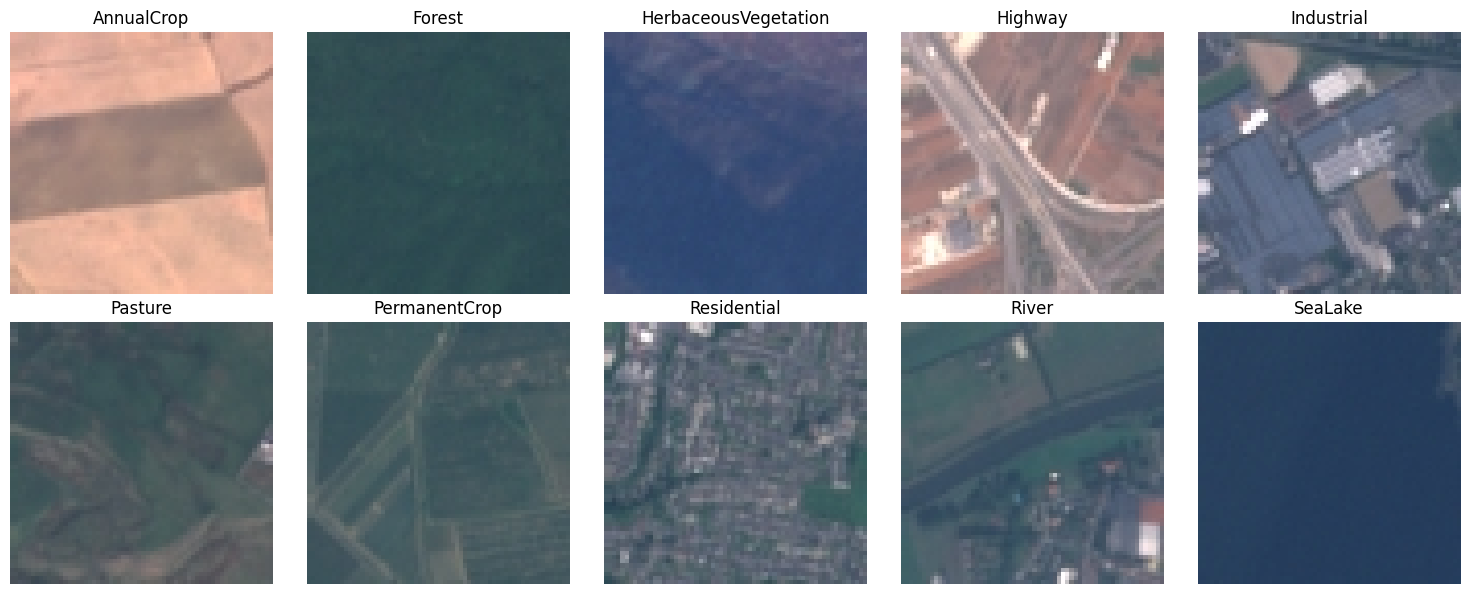

In [7]:
classes = sorted([
    name for name in os.listdir(rgb_path)
    if os.path.isdir(os.path.join(rgb_path, name))
])

plt.figure(figsize=(15, 6))

for i, class_name in enumerate(classes):
    class_path = os.path.join(rgb_path, class_name)
    image_name = os.listdir(class_path)[0]
    image = Image.open(os.path.join(class_path, image_name))

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [8]:
dataset = ImageFolder(rgb_path, transform=transform)

train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))

print("Total:", len(dataset))
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Batch shape:", images.shape)
print("Classes:", dataset.classes)

Total: 27000
Train: 18900
Validation: 4050
Test: 4050
Batch shape: torch.Size([32, 3, 64, 64])
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


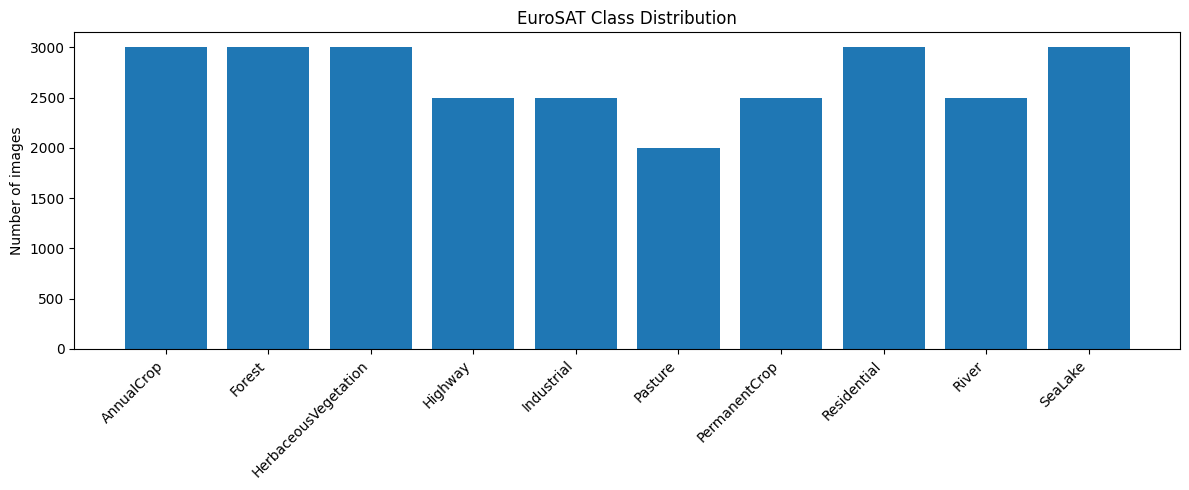

In [11]:
import matplotlib.pyplot as plt

class_counts = {
    class_name: len(os.listdir(os.path.join(rgb_path, class_name)))
    for class_name in dataset.classes
}

plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of images")
plt.title("EuroSAT Class Distribution")
plt.tight_layout()
plt.show()

In [9]:
import torch.nn as nn

class CNNBackbone(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.features(x)


cnn = CNNBackbone().cuda()

# Check output shape
with torch.no_grad():
    feature_map = cnn(images.cuda())

print("Input shape :", images.shape)
print("Feature map :", feature_map.shape)

Input shape : torch.Size([32, 3, 64, 64])
Feature map : torch.Size([32, 32, 16, 16])


In [10]:
class Tokenizer(nn.Module):
    def __init__(self, feature_dim=32, num_tokens=256):
        super().__init__()

        self.feature_dim = feature_dim
        self.num_tokens = num_tokens

        # Learnable positional embedding
        self.pos_embedding = nn.Parameter(
            torch.randn(1, num_tokens, feature_dim)
        )

    def forward(self, x):
        # x: [batch, 32, 16, 16]
        x = x.flatten(2)          # [batch, 32, 256]
        x = x.transpose(1, 2)     # [batch, 256, 32]

        # Add positional information
        x = x + self.pos_embedding

        return x


tokenizer = Tokenizer().cuda()

with torch.no_grad():
    tokens = tokenizer(feature_map)

print("Feature map :", feature_map.shape)
print("Tokens      :", tokens.shape)


Feature map : torch.Size([32, 32, 16, 16])
Tokens      : torch.Size([32, 256, 32])


In [11]:
class TransformerEncoder(nn.Module):
    def __init__(self, feature_dim=32, num_heads=8, num_layers=4, dropout=0.1):
        super().__init__()

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=feature_dim,
            nhead=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

    def forward(self, x):
        return self.transformer(x)


transformer = TransformerEncoder().cuda()

with torch.no_grad():
    transformer_output = transformer(tokens)

print("Input tokens :", tokens.shape)
print("Transformer output :", transformer_output.shape)

Input tokens : torch.Size([32, 256, 32])
Transformer output : torch.Size([32, 256, 32])


In [12]:
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.cnn = CNNBackbone()
        self.tokenizer = Tokenizer()
        self.transformer = TransformerEncoder()

        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        # CNN feature extraction
        x = self.cnn(x)                    # [B, 32, 16, 16]

        # Tokenization + positional encoding
        x = self.tokenizer(x)              # [B, 256, 32]

        # Transformer
        x = self.transformer(x)             # [B, 256, 32]

        # Global average pooling
        x = x.mean(dim=1)                   # [B, 32]

        # Classification
        x = self.classifier(x)              # [B, 10]

        return x


model = HybridCNNTransformer(num_classes=len(dataset.classes)).cuda()

print(model)

# Test one batch
with torch.no_grad():
    output = model(images.cuda())

print("\nInput :", images.shape)
print("Output:", output.shape)

HybridCNNTransformer(
  (cnn): CNNBackbone(
    (features): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (tokenizer): Tokenizer()
  (transformer): TransformerEncoder(
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-3): 4 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
          )
          (linear1): Linear(in_features=32, o

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

num_epochs = 10

print("Loss      :", criterion)
print("Optimizer :", optimizer)
print("Epochs    :", num_epochs)

Loss      : CrossEntropyLoss()
Optimizer : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Epochs    : 10


In [16]:
# already ran till 100 epoch- Epoch [078/100] Train Loss: 0.1784 | Train Acc: 93.53% | Val Loss: 0.2210 | Val Acc: 92.89% was the best (runtime error wiped the memory)
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0.0

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.cuda(), labels.cuda()

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # ---- Validation ----
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / total
    val_acc = 100 * correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_hybrid_model.pth")

    # Save latest model
    torch.save(model.state_dict(), "latest_hybrid_model.pth")

    print(
        f"Epoch [{epoch+1:03d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch [001/10] Train Loss: 1.3008 | Train Acc: 56.14% | Val Loss: 0.9474 | Val Acc: 68.81%
Epoch [002/10] Train Loss: 0.9246 | Train Acc: 68.69% | Val Loss: 0.7752 | Val Acc: 72.25%
Epoch [003/10] Train Loss: 0.8103 | Train Acc: 71.35% | Val Loss: 0.6770 | Val Acc: 75.38%
Epoch [004/10] Train Loss: 0.7591 | Train Acc: 72.89% | Val Loss: 0.6400 | Val Acc: 76.37%
Epoch [005/10] Train Loss: 0.7057 | Train Acc: 75.05% | Val Loss: 0.6285 | Val Acc: 77.53%
Epoch [006/10] Train Loss: 0.6735 | Train Acc: 76.02% | Val Loss: 0.5905 | Val Acc: 78.59%
Epoch [007/10] Train Loss: 0.6485 | Train Acc: 76.88% | Val Loss: 0.5585 | Val Acc: 80.25%
Epoch [008/10] Train Loss: 0.6237 | Train Acc: 77.78% | Val Loss: 0.5592 | Val Acc: 79.98%
Epoch [009/10] Train Loss: 0.5970 | Train Acc: 78.69% | Val Loss: 0.5483 | Val Acc: 80.25%
Epoch [010/10] Train Loss: 0.5912 | Train Acc: 79.02% | Val Loss: 0.4981 | Val Acc: 82.77%

Best Validation Accuracy: 82.77%


In [17]:
model.load_state_dict(
    torch.load("best_hybrid_model.pth", weights_only=True)
)

model.eval()

correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.cuda(), labels.cuda()

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_loss /= total
test_acc = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.4929
Test Accuracy: 82.57%


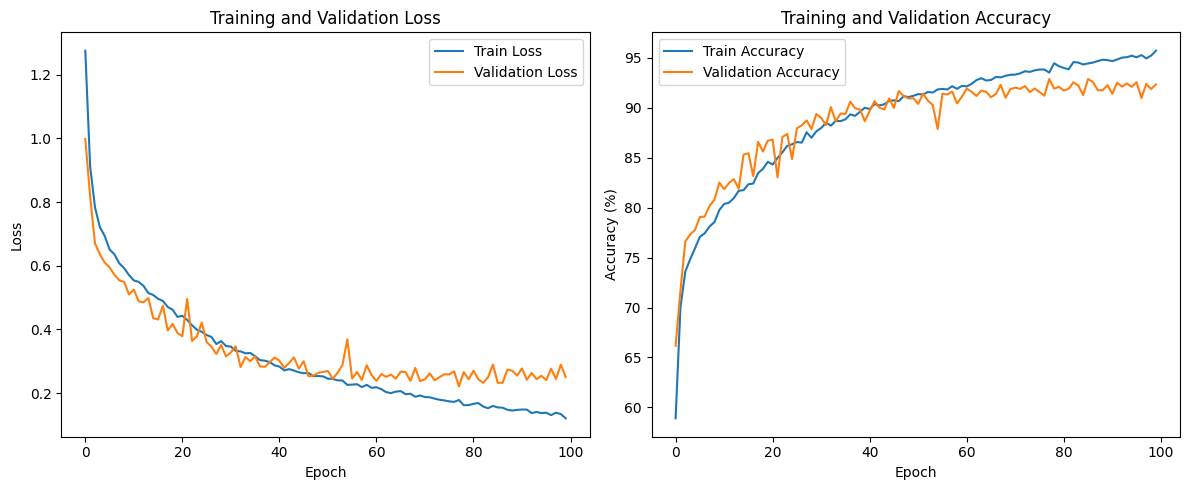

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

                      precision    recall  f1-score   support

          AnnualCrop     0.9414    0.9195    0.9303       472
              Forest     0.9540    0.9864    0.9700       442
HerbaceousVegetation     0.9020    0.9039    0.9029       458
             Highway     0.9113    0.8670    0.8886       391
          Industrial     0.9642    0.9259    0.9447       378
             Pasture     0.8727    0.9398    0.9050       299
       PermanentCrop     0.8627    0.8786    0.8706       379
         Residential     0.9630    0.9844    0.9736       450
               River     0.8913    0.8747    0.8829       375
             SeaLake     0.9726    0.9631    0.9678       406

            accuracy                         0.9257      4050
           macro avg     0.9235    0.9243    0.9236      4050
        weighted avg     0.9260    0.9257    0.9256      4050



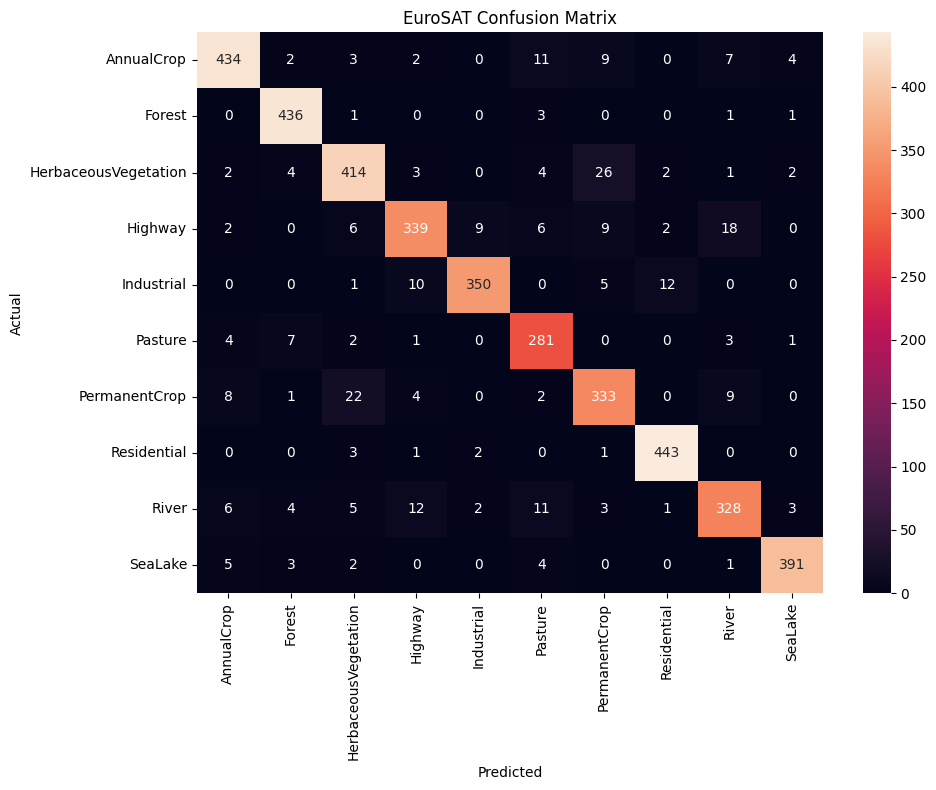

In [21]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.cuda(), labels.cuda()

        outputs = model(images)
        _, predicted = outputs.max(1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

print(classification_report(
    all_labels,
    all_predictions,
    target_names=dataset.classes,
    digits=4
))

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EuroSAT Confusion Matrix")
plt.tight_layout()
plt.show()

In [22]:
import numpy as np

cm = confusion_matrix(all_labels, all_predictions)

class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

for class_name, accuracy in zip(dataset.classes, class_accuracy):
    print(f"{class_name:25s}: {accuracy:.2f}%")

AnnualCrop               : 91.95%
Forest                   : 98.64%
HerbaceousVegetation     : 90.39%
Highway                  : 86.70%
Industrial               : 92.59%
Pasture                  : 93.98%
PermanentCrop            : 87.86%
Residential              : 98.44%
River                    : 87.47%
SeaLake                  : 96.31%


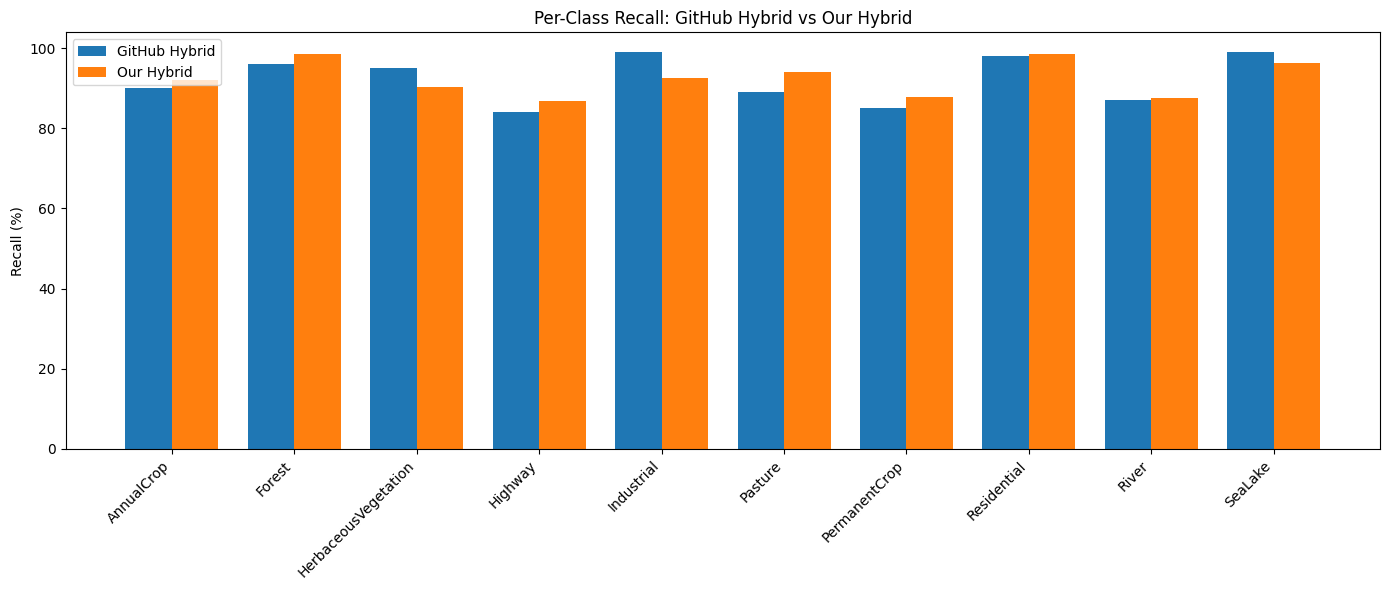

In [23]:
import numpy as np
import matplotlib.pyplot as plt

classes = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway",
    "Industrial", "Pasture", "PermanentCrop", "Residential",
    "River", "SeaLake"
]

github = [90.00, 96.00, 95.00, 84.00, 99.00, 89.00, 85.00, 98.00, 87.00, 99.00]

ours = [91.95, 98.64, 90.39, 86.70, 92.59, 93.98, 87.86, 98.44, 87.47, 96.31]

x = np.arange(len(classes))
width = 0.38

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, github, width, label="GitHub Hybrid")
plt.bar(x + width/2, ours, width, label="Our Hybrid")

plt.xticks(x, classes, rotation=45, ha="right")
plt.ylabel("Recall (%)")
plt.title("Per-Class Recall: GitHub Hybrid vs Our Hybrid")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
import torch
import torch.nn as nn

class PaperCNNTransformer(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # 1. CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 2. Learnable positional embeddings
        self.pos_embedding = nn.Parameter(
            torch.randn(1, 256, 32) * 0.02
        )

        # 3. Transformer: 4 layers, 8 heads
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=8,
            dim_feedforward=128,
            dropout=0.1,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4,
            enable_nested_tensor=False
        )

        # 4. Classification head
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        # CNN: [B, 3, 64, 64] -> [B, 32, 16, 16]
        x = self.cnn(x)

        # Tokenization: [B, 32, 16, 16] -> [B, 256, 32]
        x = x.flatten(2).transpose(1, 2)

        # Positional encoding
        x = x + self.pos_embedding

        # Transformer
        x = self.transformer(x)

        # Global average pooling
        x = x.mean(dim=1)

        # Classification logits
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

paper_model = PaperCNNTransformer(num_classes=10).to(device)

# Verify model with a sample batch
images, labels = next(iter(train_loader))
images = images.to(device)

paper_model.eval()
with torch.no_grad():
    outputs = paper_model(images)

print("Device:", device)
print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Transformer layers:", len(paper_model.transformer.layers))
print("Attention heads:", paper_model.transformer.layers[0].self_attn.num_heads)
print("Total parameters:", sum(p.numel() for p in paper_model.parameters()))

Device: cuda
Input shape: torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 10])
Transformer layers: 4
Attention heads: 8
Total parameters: 64522


In [21]:
class CNNTransformerFusion(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Positional encoding
        self.pos_embedding = nn.Parameter(
            torch.randn(1, 256, 32) * 0.02
        )

        # 4-layer, 8-head Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=8,
            dim_feedforward=128,
            dropout=0.1,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4,
            enable_nested_tensor=False
        )

        # Feature fusion:
        # CNN pooled feature (32) + Transformer pooled feature (32)
        # -> 64 -> 32
        self.fusion = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # Classification
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        # CNN features
        cnn_features = self.cnn(x)                 # [B, 32, 16, 16]

        # Tokenization
        tokens = cnn_features.flatten(2).transpose(1, 2)  # [B, 256, 32]

        # Positional encoding
        tokens = tokens + self.pos_embedding

        # Transformer
        transformer_features = self.transformer(tokens)   # [B, 256, 32]

        # Global representations
        cnn_global = cnn_features.mean(dim=(2, 3))       # [B, 32]
        transformer_global = transformer_features.mean(dim=1)  # [B, 32]

        # Feature fusion
        fused = torch.cat(
            [cnn_global, transformer_global],
            dim=1
        )                                                  # [B, 64]

        fused = self.fusion(fused)                         # [B, 32]

        # Classification
        return self.classifier(fused)


# Create model
fusion_model = CNNTransformerFusion(num_classes=10).to(device)

# Verify dimensions
fusion_model.eval()

with torch.no_grad():
    outputs = fusion_model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Parameters:", sum(p.numel() for p in fusion_model.parameters()))

Input shape: torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 10])
Parameters: 66602


In [22]:
class CompleteHybridModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # CNN
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Positional encoding
        self.pos_embedding = nn.Parameter(
            torch.randn(1, 256, 32) * 0.02
        )

        # Transformer: 4 layers, 8 heads
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=8,
            dim_feedforward=128,
            dropout=0.1,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4,
            enable_nested_tensor=False
        )

        # Feature fusion
        self.fusion = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # Attention module
        self.attention = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.Sigmoid()
        )

        # Classification
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):

        # CNN features
        cnn_features = self.cnn(x)                  # [B,32,16,16]

        # Tokenization
        tokens = cnn_features.flatten(2).transpose(1, 2)  # [B,256,32]

        # Positional encoding
        tokens = tokens + self.pos_embedding

        # Transformer
        transformer_features = self.transformer(tokens)   # [B,256,32]

        # Global representations
        cnn_global = cnn_features.mean(dim=(2, 3))       # [B,32]
        transformer_global = transformer_features.mean(dim=1)  # [B,32]

        # Feature fusion
        fused = torch.cat(
            [cnn_global, transformer_global],
            dim=1
        )                                                  # [B,64]

        fused = self.fusion(fused)                         # [B,32]

        # Attention
        attention_weights = self.attention(fused)         # [B,32]
        attended = fused * attention_weights              # [B,32]

        # Classification
        return self.classifier(attended)


# Create complete model
complete_model = CompleteHybridModel(num_classes=10).to(device)

# Verify
complete_model.eval()

with torch.no_grad():
    outputs = complete_model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print(
    "Parameters:",
    sum(p.numel() for p in complete_model.parameters())
)

Input shape: torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 10])
Parameters: 68714


In [23]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

# Paper-inspired training augmentation
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# No augmentation for validation/test
eval_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Create separate datasets so each split can have its own transform
train_full = ImageFolder(root=rgb_path, transform=train_transform)
eval_full = ImageFolder(root=rgb_path, transform=eval_transform)

# Same split indices for both datasets
train_size = int(0.70 * len(train_full))
val_size = int(0.15 * len(train_full))
test_size = len(train_full) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_indices, val_indices, test_indices = random_split(
    range(len(train_full)),
    [train_size, val_size, test_size],
    generator=generator
)

# Apply the same indices to the differently-transformed datasets
train_dataset = torch.utils.data.Subset(train_full, train_indices.indices)
val_dataset = torch.utils.data.Subset(eval_full, val_indices.indices)
test_dataset = torch.utils.data.Subset(eval_full, test_indices.indices)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 18900
Validation: 4050
Test: 4050


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

# Fresh model
complete_model = CompleteHybridModel(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(complete_model.parameters(), lr=0.0001)

num_epochs = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

best_val_accuracy = 0.0
best_model_state = None

start_time = time.time()

for epoch in range(num_epochs):
    # ---- Training ----
    complete_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device, non_blocking=True)
        labels_batch = labels_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = complete_model(images_batch)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images_batch.size(0)
        correct += (outputs.argmax(1) == labels_batch).sum().item()
        total += labels_batch.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # ---- Validation ----
    complete_model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device, non_blocking=True)
            labels_batch = labels_batch.to(device, non_blocking=True)

            outputs = complete_model(images_batch)
            loss = criterion(outputs, labels_batch)

            val_loss_total += loss.item() * images_batch.size(0)
            val_correct += (outputs.argmax(1) == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    val_loss = val_loss_total / val_total
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = {
            k: v.detach().cpu().clone()
            for k, v in complete_model.state_dict().items()
        }

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"Time: {elapsed/60:.1f} min"
    )

# Restore best validation model
complete_model.load_state_dict(best_model_state)

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")
print(f"Total time: {(time.time()-start_time)/60:.1f} min")

Epoch [01/10] | Train Loss: 1.7518 | Train Acc: 38.38% | Val Loss: 1.2887 | Val Acc: 52.57% | Time: 0.6 min
Epoch [02/10] | Train Loss: 1.1849 | Train Acc: 56.91% | Val Loss: 0.8840 | Val Acc: 67.98% | Time: 1.0 min
Epoch [03/10] | Train Loss: 0.9712 | Train Acc: 64.59% | Val Loss: 0.8002 | Val Acc: 70.67% | Time: 1.5 min
Epoch [04/10] | Train Loss: 0.8708 | Train Acc: 68.83% | Val Loss: 0.7554 | Val Acc: 72.40% | Time: 2.1 min
Epoch [05/10] | Train Loss: 0.7987 | Train Acc: 71.65% | Val Loss: 0.6688 | Val Acc: 75.60% | Time: 2.6 min
Epoch [06/10] | Train Loss: 0.7577 | Train Acc: 72.69% | Val Loss: 0.6534 | Val Acc: 76.32% | Time: 3.2 min
Epoch [07/10] | Train Loss: 0.7261 | Train Acc: 74.22% | Val Loss: 0.5925 | Val Acc: 78.86% | Time: 3.7 min
Epoch [08/10] | Train Loss: 0.7017 | Train Acc: 74.87% | Val Loss: 0.5769 | Val Acc: 79.48% | Time: 4.2 min
Epoch [09/10] | Train Loss: 0.6799 | Train Acc: 75.48% | Val Loss: 0.5645 | Val Acc: 79.88% | Time: 4.8 min
Epoch [10/10] | Train Loss: 

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import time

# Fresh CNN + Transformer model
transformer_model = PaperCNNTransformer(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(transformer_model.parameters(), lr=0.0001)

num_epochs = 10

train_losses_t, val_losses_t = [], []
train_accuracies_t, val_accuracies_t = [], []

best_val_accuracy_t = 0.0
best_model_state_t = None

start_time = time.time()

for epoch in range(num_epochs):

    # Training
    transformer_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images_batch, labels_batch in train_loader:
        images_batch = images_batch.to(device, non_blocking=True)
        labels_batch = labels_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = transformer_model(images_batch)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images_batch.size(0)
        correct += (outputs.argmax(1) == labels_batch).sum().item()
        total += labels_batch.size(0)

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # Validation
    transformer_model.eval()
    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images_batch, labels_batch in val_loader:
            images_batch = images_batch.to(device, non_blocking=True)
            labels_batch = labels_batch.to(device, non_blocking=True)

            outputs = transformer_model(images_batch)
            loss = criterion(outputs, labels_batch)

            val_loss_total += loss.item() * images_batch.size(0)
            val_correct += (outputs.argmax(1) == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    val_loss = val_loss_total / val_total
    val_acc = 100 * val_correct / val_total

    train_losses_t.append(train_loss)
    val_losses_t.append(val_loss)
    train_accuracies_t.append(train_acc)
    val_accuracies_t.append(val_acc)

    if val_acc > best_val_accuracy_t:
        best_val_accuracy_t = val_acc
        best_model_state_t = {
            k: v.detach().cpu().clone()
            for k, v in transformer_model.state_dict().items()
        }

    elapsed = time.time() - start_time

    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"Time: {elapsed/60:.1f} min"
    )

transformer_model.load_state_dict(best_model_state_t)

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_accuracy_t:.2f}%")
print(f"Total time: {(time.time()-start_time)/60:.1f} min")

Epoch [01/10] | Train Loss: 1.3798 | Train Acc: 51.62% | Val Loss: 0.9318 | Val Acc: 66.91% | Time: 0.6 min
Epoch [02/10] | Train Loss: 0.9195 | Train Acc: 67.37% | Val Loss: 0.7013 | Val Acc: 74.00% | Time: 1.0 min
Epoch [03/10] | Train Loss: 0.7577 | Train Acc: 73.17% | Val Loss: 0.6268 | Val Acc: 78.27% | Time: 1.5 min
Epoch [04/10] | Train Loss: 0.6937 | Train Acc: 75.41% | Val Loss: 0.6307 | Val Acc: 76.99% | Time: 2.0 min
Epoch [05/10] | Train Loss: 0.6484 | Train Acc: 76.85% | Val Loss: 0.5336 | Val Acc: 81.01% | Time: 2.5 min
Epoch [06/10] | Train Loss: 0.6158 | Train Acc: 78.02% | Val Loss: 0.5633 | Val Acc: 80.37% | Time: 3.1 min
Epoch [07/10] | Train Loss: 0.5854 | Train Acc: 79.14% | Val Loss: 0.5254 | Val Acc: 81.48% | Time: 3.6 min
Epoch [08/10] | Train Loss: 0.5656 | Train Acc: 80.13% | Val Loss: 0.4761 | Val Acc: 83.43% | Time: 4.1 min
Epoch [09/10] | Train Loss: 0.5500 | Train Acc: 80.70% | Val Loss: 0.4881 | Val Acc: 83.46% | Time: 4.6 min
Epoch [10/10] | Train Loss: 

In [24]:
import torch
import torch.nn as nn

class PaperHybridModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # 1. CNN: local spatial feature extraction
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 2. Positional encoding for 256 tokens
        self.pos_embedding = nn.Parameter(
            torch.randn(1, 256, 32) * 0.02
        )

        # 3. Transformer encoder: 4 layers, 8 heads
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=8,
            dim_feedforward=128,
            dropout=0.1,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4,
            enable_nested_tensor=False
        )

        # 4. Feature fusion
        # CNN global feature (32) + Transformer global feature (32)
        self.fusion = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # 5. Attention enhancement
        self.attention = nn.Sequential(
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.Sigmoid()
        )

        # 6. Classification head
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):

        # CNN feature map: [B, 32, 16, 16]
        cnn_features = self.cnn(x)

        # CNN global representation: [B, 32]
        cnn_global = cnn_features.mean(dim=(2, 3))

        # Convert feature map to 256 tokens: [B, 256, 32]
        tokens = cnn_features.flatten(2).transpose(1, 2)

        # Add positional encoding
        tokens = tokens + self.pos_embedding

        # Transformer: [B, 256, 32]
        transformer_features = self.transformer(tokens)

        # Global Transformer representation: [B, 32]
        transformer_global = transformer_features.mean(dim=1)

        # Feature fusion: [B, 64] → [B, 32]
        fused = torch.cat(
            [cnn_global, transformer_global],
            dim=1
        )

        fused = self.fusion(fused)

        # Attention enhancement
        attention_weights = self.attention(fused)
        attended = fused * attention_weights

        # Classification
        output = self.classifier(attended)

        return output


# Create model
paper_model = PaperHybridModel(num_classes=10).to(device)

print(paper_model)

# Forward-pass verification
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    output = paper_model(sample_images)

print("\nInput shape :", sample_images.shape)
print("Output shape:", output.shape)
print("Parameters  :", sum(p.numel() for p in paper_model.parameters()))

PaperHybridModel(
  (cnn): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(paper_specified_model.parameters(), lr=0.0001)

num_epochs = 10
train_history = []
val_history = []

for epoch in range(num_epochs):

    # ---- Training ----
    paper_specified_model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = paper_specified_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ---- Validation ----
    paper_specified_model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = paper_specified_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_history.append(train_acc)
    val_history.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

print(f"\nBest Validation Accuracy: {max(val_history)*100:.2f}%")

NameError: name 'paper_specified_model' is not defined

In [26]:
import torch
import torch.nn as nn

class PaperSpecifiedModel(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # CNN backbone
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # 256 tokens × 32 features
        self.pos_embedding = nn.Parameter(
            torch.randn(1, 256, 32) * 0.02
        )

        # Paper: 4 Transformer layers, 8 attention heads
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=32,
            nhead=8,
            dim_feedforward=128,
            dropout=0.1,
            activation="relu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4,
            enable_nested_tensor=False
        )

        # Global average pooling + classifier
        self.classifier = nn.Linear(32, num_classes)

    def forward(self, x):
        # [B, 3, 64, 64] → [B, 32, 16, 16]
        x = self.cnn(x)

        # [B, 32, 16, 16] → [B, 256, 32]
        x = x.flatten(2).transpose(1, 2)

        # Positional encoding
        x = x + self.pos_embedding

        # Transformer
        x = self.transformer(x)

        # Global average pooling over tokens
        x = x.mean(dim=1)

        # Classification
        return self.classifier(x)


paper_specified_model = PaperSpecifiedModel(num_classes=10).to(device)

print(paper_specified_model)

# Shape verification
sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(device)

with torch.no_grad():
    output = paper_specified_model(sample_images)

print("\nInput shape :", sample_images.shape)
print("Output shape:", output.shape)
print(
    "Parameters  :",
    sum(p.numel() for p in paper_specified_model.parameters())
)

PaperSpecifiedModel(
  (cnn): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_featur

In [27]:
# Fresh model for the full 100-epoch experiment
paper_specified_model = PaperSpecifiedModel(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(paper_specified_model.parameters(), lr=0.0001)

num_epochs = 100
train_history = []
val_history = []
train_loss_history = []
val_loss_history = []

best_val_acc = 0.0
best_epoch = 0

for epoch in range(num_epochs):

    # ---- Training ----
    paper_specified_model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = paper_specified_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ---- Validation ----
    paper_specified_model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = paper_specified_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_history.append(train_acc)
    val_history.append(val_acc)
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save(
            paper_specified_model.state_dict(),
            "best_paper_specified_model.pth"
        )

    print(
        f"Epoch {epoch+1:03d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

print(f"\nBest Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"Best Epoch: {best_epoch}")

Epoch 001/100 | Train Loss: 1.4247 | Train Acc: 48.96% | Val Loss: 1.0578 | Val Acc: 63.36%
Epoch 002/100 | Train Loss: 0.9796 | Train Acc: 64.27% | Val Loss: 0.7967 | Val Acc: 71.23%
Epoch 003/100 | Train Loss: 0.8409 | Train Acc: 69.46% | Val Loss: 0.7753 | Val Acc: 71.53%
Epoch 004/100 | Train Loss: 0.7531 | Train Acc: 72.95% | Val Loss: 0.7034 | Val Acc: 73.46%
Epoch 005/100 | Train Loss: 0.7054 | Train Acc: 74.47% | Val Loss: 0.6079 | Val Acc: 77.58%
Epoch 006/100 | Train Loss: 0.6585 | Train Acc: 76.50% | Val Loss: 0.6041 | Val Acc: 77.90%
Epoch 007/100 | Train Loss: 0.6400 | Train Acc: 76.90% | Val Loss: 0.5654 | Val Acc: 79.88%
Epoch 008/100 | Train Loss: 0.6005 | Train Acc: 78.44% | Val Loss: 0.5245 | Val Acc: 81.01%
Epoch 009/100 | Train Loss: 0.5911 | Train Acc: 78.52% | Val Loss: 0.5248 | Val Acc: 80.42%
Epoch 010/100 | Train Loss: 0.5703 | Train Acc: 79.51% | Val Loss: 0.4875 | Val Acc: 82.20%
Epoch 011/100 | Train Loss: 0.5591 | Train Acc: 79.89% | Val Loss: 0.4926 | Val 

In [30]:
# Load best paper-specified model
paper_specified_model.load_state_dict(
    torch.load("best_paper_specified_model.pth", weights_only=True)
)

paper_specified_model.eval()

correct = 0
total = 0
test_loss = 0.0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = paper_specified_model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= total
test_acc = 100 * correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.1813
Test Accuracy: 94.37%


In [32]:
from sklearn.metrics import classification_report

class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print(report)

                      precision    recall  f1-score   support

          AnnualCrop     0.9378    0.9576    0.9476       472
              Forest     0.9647    0.9887    0.9765       442
HerbaceousVegetation     0.9221    0.9563    0.9389       458
             Highway     0.9418    0.8696    0.9043       391
          Industrial     0.9188    0.9577    0.9378       378
             Pasture     0.9019    0.9532    0.9268       299
       PermanentCrop     0.9373    0.8681    0.9014       379
         Residential     0.9800    0.9822    0.9811       450
               River     0.9339    0.9040    0.9187       375
             SeaLake     0.9851    0.9803    0.9827       406

            accuracy                         0.9437      4050
           macro avg     0.9423    0.9418    0.9416      4050
        weighted avg     0.9440    0.9437    0.9434      4050



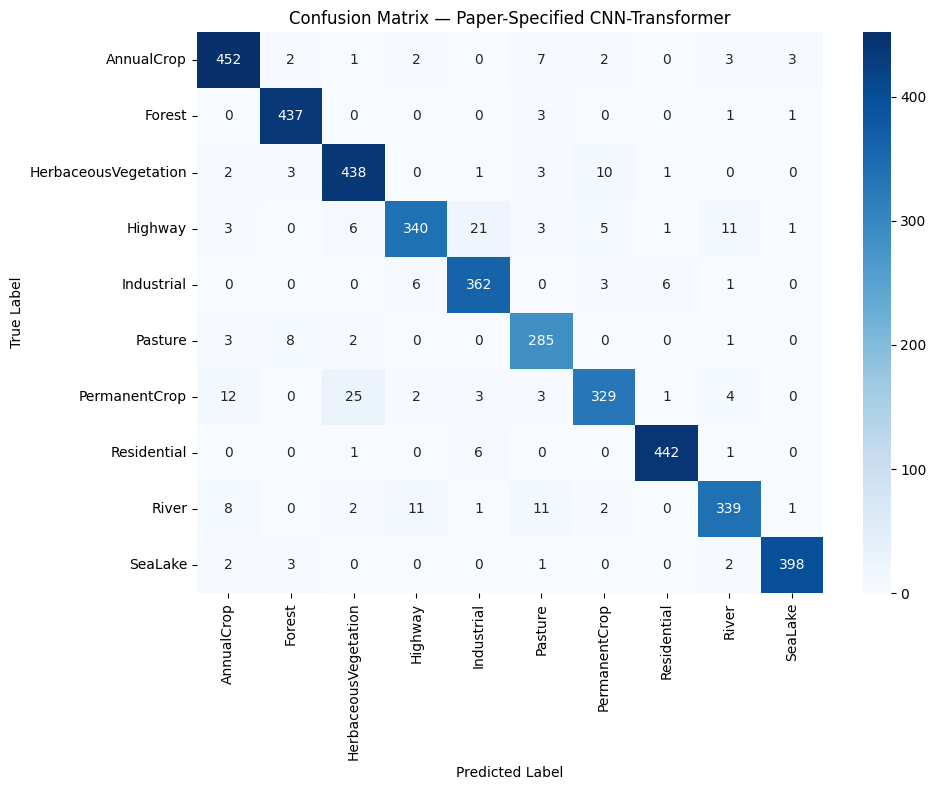

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Paper-Specified CNN-Transformer")
plt.tight_layout()
plt.show()

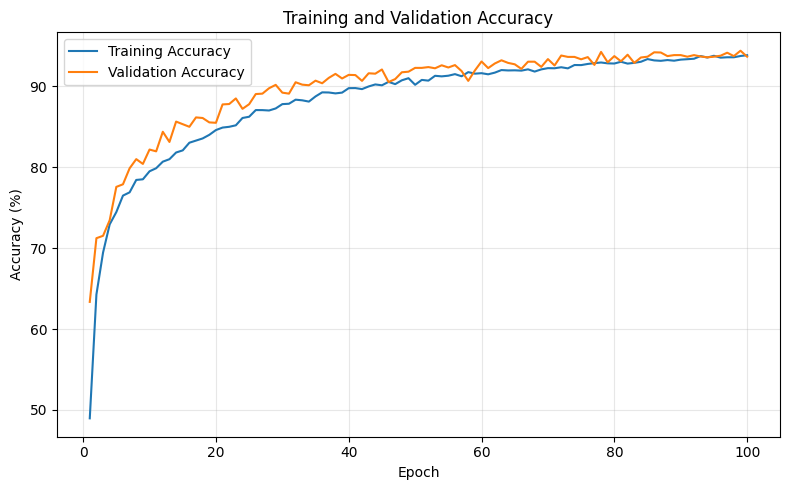

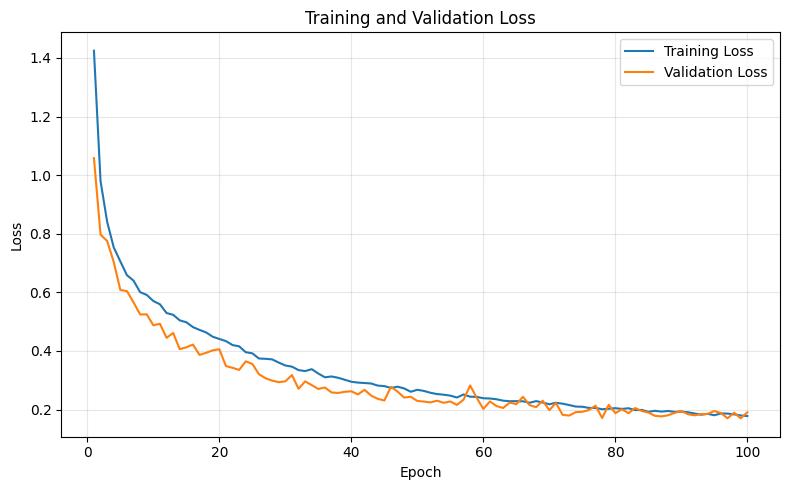

In [34]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_history) + 1)

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, [x * 100 for x in train_history], label="Training Accuracy")
plt.plot(epochs, [x * 100 for x in val_history], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_history, label="Training Loss")
plt.plot(epochs, val_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

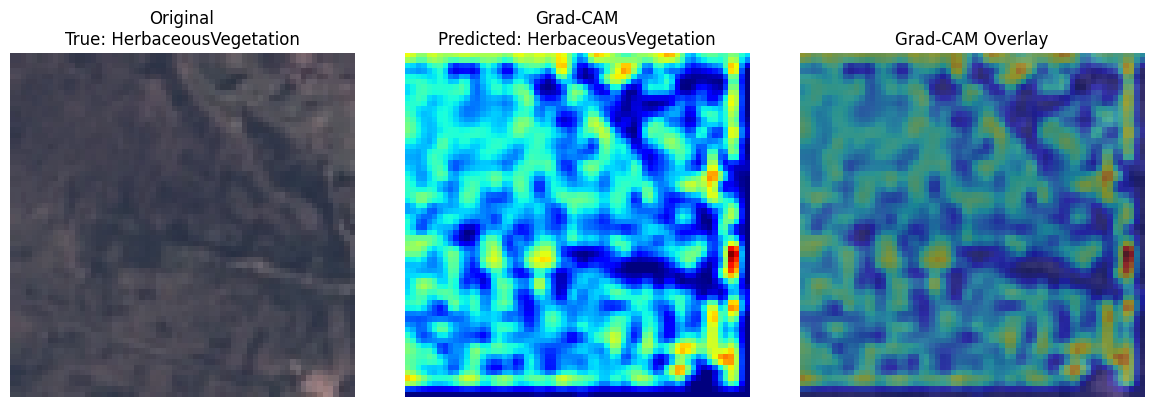

In [35]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Use the last CNN convolutional layer
target_layer = paper_specified_model.cnn[6]

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# Get one test image
images, labels = next(iter(test_loader))
image = images[0:1].to(device)
label = labels[0].item()

paper_specified_model.eval()

# Forward pass
output = paper_specified_model(image)
predicted = output.argmax(dim=1).item()

# Backward pass for predicted class
paper_specified_model.zero_grad()
output[0, predicted].backward()

# Grad-CAM
weights = gradients.mean(dim=(2, 3), keepdim=True)
cam = (weights * activations).sum(dim=1, keepdim=True)
cam = F.relu(cam)

cam = F.interpolate(
    cam,
    size=(64, 64),
    mode="bilinear",
    align_corners=False
)

cam = cam.squeeze().detach().cpu().numpy()

# Normalize
cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

# Original image
original = images[0].permute(1, 2, 0).cpu().numpy()

# Undo ImageNet normalization for visualization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

original = original * std + mean
original = np.clip(original, 0, 1)

# Plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title(f"Original\nTrue: {class_names[label]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title(f"Grad-CAM\nPredicted: {class_names[predicted]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original)
plt.imshow(cam, cmap="jet", alpha=0.45)
plt.title("Grad-CAM Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

forward_handle.remove()
backward_handle.remove()

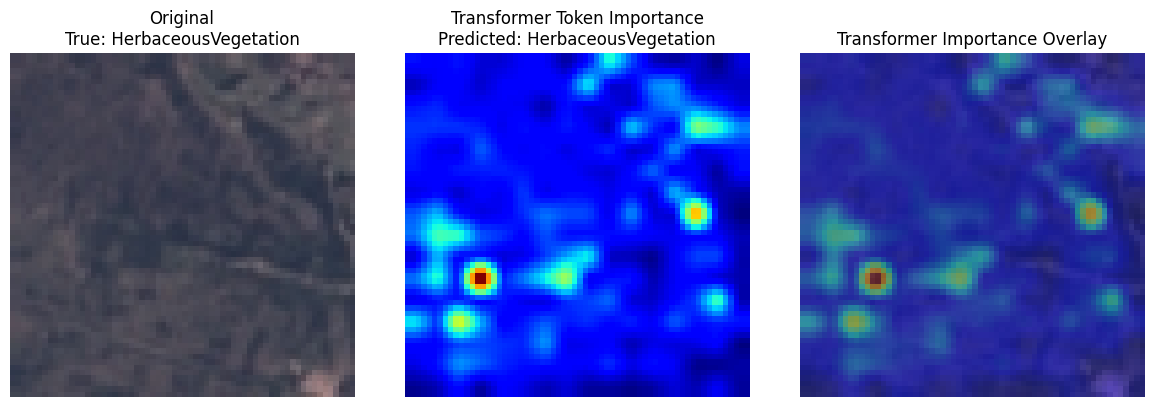

In [37]:
# Transformer token-importance visualization

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

paper_specified_model.eval()

# Get one test image
images, labels = next(iter(test_loader))
image = images[0:1].to(device)
label = labels[0].item()

# Capture CNN feature map
with torch.no_grad():
    cnn_features = paper_specified_model.cnn(image)

# Convert CNN features to tokens
tokens = cnn_features.flatten(2).transpose(1, 2)

# Enable gradients for token importance
tokens = tokens.detach().requires_grad_(True)

# Add positional encoding
tokens_with_pos = tokens + paper_specified_model.pos_embedding

# Transformer
transformer_output = paper_specified_model.transformer(tokens_with_pos)

# Global average pooling + classifier
pooled = transformer_output.mean(dim=1)
output = paper_specified_model.classifier(pooled)

predicted = output.argmax(dim=1).item()

# Backpropagate predicted class
paper_specified_model.zero_grad()
output[0, predicted].backward()

# Token importance from gradients
importance = tokens.grad.abs().mean(dim=2)

# Reshape 256 tokens -> 16x16
importance = importance.reshape(16, 16)

# Normalize
importance = importance.detach().cpu().numpy()
importance = (importance - importance.min()) / (
    importance.max() - importance.min() + 1e-8
)

# Resize to image size
importance_tensor = torch.tensor(importance).unsqueeze(0).unsqueeze(0)

importance_resized = F.interpolate(
    importance_tensor,
    size=(64, 64),
    mode="bilinear",
    align_corners=False
).squeeze().numpy()

# Original image
original = images[0].permute(1, 2, 0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

original = original * std + mean
original = np.clip(original, 0, 1)

# Visualization
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title(f"Original\nTrue: {class_names[label]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(importance_resized, cmap="jet")
plt.title(f"Transformer Token Importance\nPredicted: {class_names[predicted]}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(original)
plt.imshow(importance_resized, cmap="jet", alpha=0.45)
plt.title("Transformer Importance Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# FINAL EXPERIMENT SUMMARY
# ============================================================

print("""
============================================================
        EuroSAT CNN–Transformer Experiment Summary
============================================================

DATASET
-------
Dataset: EuroSAT RGB
Total images: 27,000
Number of classes: 10
Input size: 64 × 64 × 3

The original GitHub implementation used the same dataset
directory for training, validation, and testing, which causes
data leakage.

To avoid this, the dataset was split properly into:
    • 70% Training
    • 15% Validation
    • 15% Testing

Data augmentation was applied only to the training set.


MODEL
-----
The model follows the architecture explicitly described in
the paper:

    RGB Image
        ↓
    CNN Feature Extraction
        ↓
    32 × 16 × 16 Feature Map
        ↓
    256 Tokens × 32 Features
        ↓
    Learnable Positional Embedding
        ↓
    4-Layer Transformer Encoder
        ↓
    8 Attention Heads
        ↓
    Global Average Pooling
        ↓
    Fully Connected Classifier
        ↓
    10 Land-Cover Classes

Total parameters: 64,522


TRAINING
--------
Optimizer: Adam
Learning rate: 0.0001
Epochs: 100
Loss function: Cross Entropy Loss

Best validation accuracy:
    94.42% at epoch 99


TEST RESULTS
------------
Test samples: 4,050
Test Loss: 0.1813
Test Accuracy: 94.37%

Macro F1-score: 94.16%
Weighted F1-score: 94.34%


CLASSIFICATION
--------------
The model performs particularly well on:

    Forest       → F1 = 97.65%
    Residential  → F1 = 98.11%
    SeaLake       → F1 = 98.27%

The relatively weaker classes are:

    PermanentCrop → F1 = 90.14%
    Highway       → F1 = 90.43%
    River         → F1 = 91.87%


VISUALIZATION
-------------
The experiment includes:

    • Training vs Validation Accuracy
    • Training vs Validation Loss
    • Confusion Matrix
    • Grad-CAM visualization
    • Transformer token-importance visualization

Grad-CAM shows which spatial regions of the CNN feature
representation contribute to the prediction.

The Transformer token-importance visualization shows which
image tokens have greater gradient-based importance for the
predicted class.


INTERPRETATION
--------------
The model successfully combines CNN-based local spatial
features with Transformer-based global contextual features.

The obtained test accuracy is 94.37%.

The paper reports 98.36%, but this experiment should not be
considered an exact reproduction of that number because the
provided implementation and paper contain differences.

In particular, the GitHub implementation differs from the
paper's specified Transformer configuration, and the paper
does not provide sufficient implementation details to exactly
reconstruct its feature-fusion and attention components.

Therefore, 94.37% represents the result obtained from the
explicitly specified CNN + Transformer architecture using a
corrected dataset split and the stated training configuration.

============================================================
                    END OF EXPERIMENT
============================================================
""")


        EuroSAT CNN–Transformer Experiment Summary

DATASET
-------
Dataset: EuroSAT RGB
Total images: 27,000
Number of classes: 10
Input size: 64 × 64 × 3

The original GitHub implementation used the same dataset
directory for training, validation, and testing, which causes
data leakage.

To avoid this, the dataset was split properly into:
    • 70% Training
    • 15% Validation
    • 15% Testing

Data augmentation was applied only to the training set.


MODEL
-----
The model follows the architecture explicitly described in
the paper:

    RGB Image
        ↓
    CNN Feature Extraction
        ↓
    32 × 16 × 16 Feature Map
        ↓
    256 Tokens × 32 Features
        ↓
    Learnable Positional Embedding
        ↓
    4-Layer Transformer Encoder
        ↓
    8 Attention Heads
        ↓
    Global Average Pooling
        ↓
    Fully Connected Classifier
        ↓
    10 Land-Cover Classes

Total parameters: 64,522


TRAINING
--------
Optimizer: Adam
Learning rate: 0.0001
Epochs: 10